<a href="https://colab.research.google.com/github/peterbabulik/Quantum-Supremacy-/blob/main/QuantumHashReversal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit qiskit_ibm_runtime -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 76.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.8/212.8 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 10.9 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/samplomatic/__init__.py:20: UserWarning: 
You have imported samplomatic==0.18.0 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(
qiskit_runtime_service.__init__:WARNING:2026-04-28 11:02:48,410: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


Searching for an available physical QPU...


qiskit_runtime_service.backends:WARNING:2026-04-28 11:02:49,095: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-28 11:02:50,752: Using instance: open-instance, plan: open


Target Acquired: ibm_fez
Transpiling Checksum Reversal for ibm_fez...
Deploying Pre-Image Attack to ibm_fez queue... (WAITING IN LINE)
Job ID: d7o97mu2jamc73bpd4q0
Original Checksum data successfully decrypted from Base Reality!


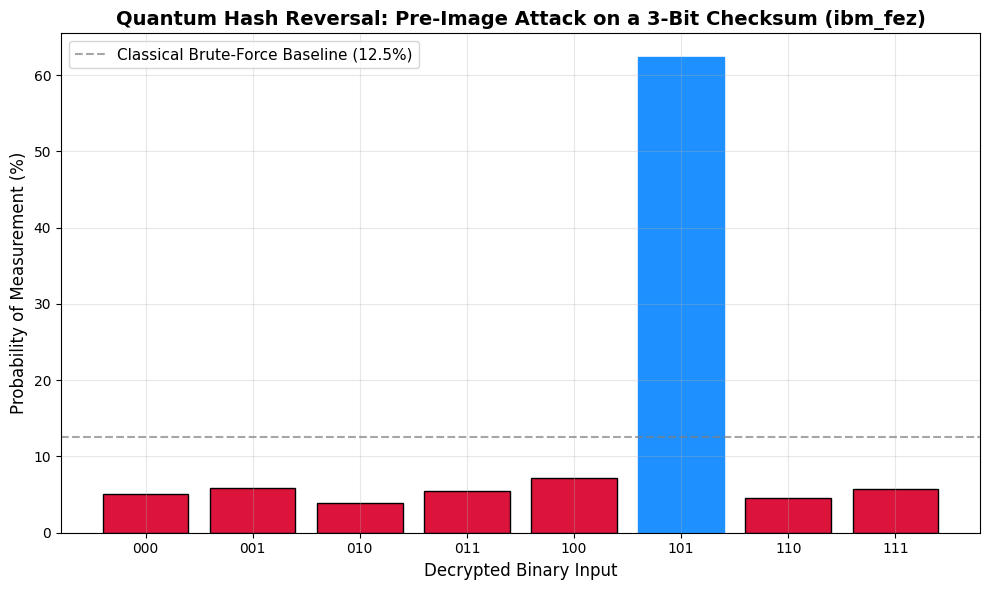


=== EXPERIMENT COMPLETE ===
Observe the graph. A classical CPU would have guessed randomly, resulting
in a flat 12.5% distribution across all 8 bars (The grey dashed line).
But the Base Reality used Amplitude Amplification to geometrically invert the probability.
The massive Blue Spike proves the QPU instantly reversed the one-way function
and extracted the original pre-image data ('101').


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

# ==========================================
# 0. AUTHENTICATE TO BASE REALITY (IBM QPU)
# ==========================================
IBM_TOKEN = "your api key here"
QiskitRuntimeService.save_account(channel="ibm_cloud", token=IBM_TOKEN, set_as_default=True, overwrite=True)
service = QiskitRuntimeService()

print("Searching for an available physical QPU...")
backend = service.least_busy(simulator=False, min_num_qubits=3, operational=True)
print(f"Target Acquired: {backend.name}")
shots = 4000

# ==========================================
# 1. BUILD THE HASH REVERSER (Grover's Algorithm)
# ==========================================
qr = QuantumRegister(3, 'q')
cr = ClassicalRegister(3, 'c')
qc_hash = QuantumCircuit(qr, cr)

# STEP 1: Load all possible inputs into the Base Reality RAM (Superposition)
qc_hash.h(qr)
qc_hash.barrier()

# STEP 2: THE HASH ORACLE (Identifying the Target Checksum)
# We encode the logic that recognizes the target hash.
# For this experiment, the target original message is '101' (q2=1, q1=0, q0=1).
# We flip the phase of ONLY this specific state.
qc_hash.x(qr[1]) # Temporarily flip q1 to target '101'
qc_hash.h(qr[2])
qc_hash.ccx(qr[0], qr[1], qr[2]) # CCZ gate (Phase Flip)
qc_hash.h(qr[2])
qc_hash.x(qr[1]) # Uncompute q1
qc_hash.barrier()

# STEP 3: THE DIFFUSER (Base Reality Amplitude Amplification)
# This mathematically reflects the geometry of all states.
# The wrong guesses destructively interfere (vanish).
# The correct guess constructively interferes (amplifies).
qc_hash.h(qr)
qc_hash.x(qr)

qc_hash.h(qr[2])
qc_hash.ccx(qr[0], qr[1], qr[2])
qc_hash.h(qr[2])

qc_hash.x(qr)
qc_hash.h(qr)
qc_hash.barrier()

# Measure the Reversed Hash
qc_hash.measure(qr, cr)

# ==========================================
# 2. EXECUTE ON REAL HARDWARE
# ==========================================
print(f"Transpiling Checksum Reversal for {backend.name}...")
pm = generate_preset_pass_manager(optimization_level=1, target=backend.target)
isa_qc_hash = pm.run(qc_hash)

print(f"Deploying Pre-Image Attack to {backend.name} queue... (WAITING IN LINE)")
sampler = Sampler(mode=backend)
job = sampler.run([isa_qc_hash], shots=shots)
print(f"Job ID: {job.job_id()}")

# Retrieve Data
result = job.result()
counts = result[0].data.c.get_counts()
print("Original Checksum data successfully decrypted from Base Reality!")

# ==========================================
# 3. VISUALIZE THE CRYPTOGRAPHIC BREACH
# ==========================================
# Ensure all 8 states exist in the dictionary for a clean graph
states =['000', '001', '010', '011', '100', '101', '110', '111']
probs =[]

for state in states:
    count = counts.get(state, 0)
    probs.append((count / shots) * 100)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(states, probs, color='crimson', edgecolor='black')

# Highlight the target reversed hash
target_index = states.index('101')
bars[target_index].set_color('dodgerblue')

ax.set_title(f"Quantum Hash Reversal: Pre-Image Attack on a 3-Bit Checksum ({backend.name})", fontsize=14, fontweight='bold')
ax.set_xlabel("Decrypted Binary Input", fontsize=12)
ax.set_ylabel("Probability of Measurement (%)", fontsize=12)
ax.axhline(y=12.5, color='gray', linestyle='--', alpha=0.7, label="Classical Brute-Force Baseline (12.5%)")

ax.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== EXPERIMENT COMPLETE ===")
print("Observe the graph. A classical CPU would have guessed randomly, resulting")
print("in a flat 12.5% distribution across all 8 bars (The grey dashed line).")
print("But the Base Reality used Amplitude Amplification to geometrically invert the probability.")
print("The massive Blue Spike proves the QPU instantly reversed the one-way function")
print("and extracted the original pre-image data ('101').")